# Sales Forecasting Using Time-Series Analysis

## Project Overview

This project develops an end-to-end time-series forecasting pipeline to analyze historical sales patterns and generate future sales forecasts.

The workflow includes data cleaning, exploratory data analysis, time-series analysis, stationarity testing, seasonal analysis, baseline forecasting, ARIMA and SARIMA modeling, model evaluation, walk-forward validation, and future sales forecasting.

The final model is used to generate a 90-day sales forecast along with prediction intervals to communicate forecast uncertainty.

## 1. Business Problem & Objective

### Business Problem

Historical sales data contains valuable information about temporal patterns and recurring demand behavior. However, historical data alone does not directly provide an estimate of future sales.

A forecasting approach is therefore required to identify temporal patterns in historical sales and use those patterns to estimate future sales.

### Objective

The primary objective of this project is to develop and evaluate a time-series forecasting model capable of predicting future daily sales.

The project aims to:

- Analyze historical sales trends.
- Identify temporal and weekly seasonal patterns.
- Establish baseline forecasting performance.
- Compare ARIMA and SARIMA forecasting models.
- Evaluate models using MAE and RMSE.
- Validate the selected model using walk-forward validation.
- Generate a 90-day future sales forecast.
- Translate the forecasting results into useful business insights.

## 2. Dataset Overview

The project uses historical sales transaction data containing information about orders, customers, geographic locations, products, and sales.

The dataset contains 9,800 records and 18 columns.

The primary target variable for forecasting is `Sales`, while `Order Date` provides the temporal dimension required for time-series analysis.

### Key Variables

| Variable | Description |
|---|---|
| `Order Date` | Date on which the order was placed |
| `Ship Date` | Date on which the order was shipped |
| `Category` | Product category |
| `Sub-Category` | Product sub-category |
| `Product Name` | Name of the product |
| `Customer ID` | Unique customer identifier |
| `Segment` | Customer segment |
| `Region` | Geographic region |
| `Sales` | Sales amount and forecasting target |

## 3. Tools & Technologies

- **Python** — Data analysis and forecasting
- **Pandas** — Data manipulation
- **NumPy** — Numerical computation
- **Matplotlib** — Data visualization
- **Statsmodels** — Statistical time-series modeling
- **Scikit-learn** — Forecast evaluation metrics
- **Jupyter Notebook** — Interactive analysis environment through VS Code

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 3.0.5
NumPy: 2.5.2


## 1. Data Loading & Initial Inspection

The dataset is loaded into a Pandas DataFrame and examined to understand its structure, dimensions, data types, and basic statistical characteristics before performing any transformations.

In [3]:
df = pd.read_csv("D:\\DATA SCIENCE MINDRISERS CLASS\\Sales-Forecasting\\data\\raw\\train.csv")

In [4]:
df.shape

(9800, 18)

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


### Initial Findings

The initial inspection identified the following characteristics:

- The dataset contains 9,800 records and 18 variables.
- There are 11 missing values in the `Postal Code` column, while the remaining columns are complete.
- No completely duplicated records were identified.
- `Order Date` and `Ship Date` are initially stored as string values and require conversion to datetime format for time-series analysis.
- Sales values show substantial variability, with a mean of approximately 230.77 and a median of approximately 54.49.
- The difference between the mean and median, together with the maximum sales value of 22,638.48, suggests that the sales distribution may be right-skewed.

## 2. Date and Time Analysis

Before converting the dataset into a forecasting time series, the date range and temporal coverage are examined to determine the appropriate time frequency and identify any missing dates.

In [12]:
df["Order Date"].head(10)

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
5    09/06/2015
6    09/06/2015
7    09/06/2015
8    09/06/2015
9    09/06/2015
Name: Order Date, dtype: str

In [13]:
df["Order Date"].min()

'01/01/2018'

In [14]:
df["Order Date"].max()

'31/12/2017'

In [15]:
df["Order Date"].nunique()

1230

In [16]:
df["Order Date"].value_counts().head(10)

Order Date
05/09/2017    38
10/11/2017    35
01/12/2018    34
02/12/2018    34
09/12/2018    33
02/09/2018    33
12/11/2018    30
08/12/2018    30
09/09/2018    29
11/12/2017    28
Name: count, dtype: int64

### Converting Order Date to Datetime

The `Order Date` column is currently stored as a string. Since time-series analysis requires chronological operations, the column will be converted to Pandas datetime format.

The dataset uses the `DD/MM/YYYY` date format, so `dayfirst=True` is specified explicitly during conversion.

In [17]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

In [18]:
df["Order Date"].dtype

dtype('<M8[us]')

In [19]:
df["Order Date"].min()

Timestamp('2015-01-03 00:00:00')

In [20]:
df["Order Date"].max()

Timestamp('2018-12-30 00:00:00')

In [21]:
df["Order Date"].nunique()

1230

### Checking the Chronological Order

The Order Date column is now stored as datetime. The dates are sorted to inspect the temporal coverage and identify potential gaps before creating the final daily time series.

In [22]:
df["Order Date"].sort_values().head(20)

7980   2015-01-03
741    2015-01-04
740    2015-01-04
739    2015-01-04
1759   2015-01-05
7478   2015-01-06
7477   2015-01-06
5327   2015-01-06
7474   2015-01-06
7480   2015-01-06
7475   2015-01-06
7180   2015-01-06
7476   2015-01-06
7479   2015-01-06
7661   2015-01-07
7660   2015-01-07
593    2015-01-09
592    2015-01-09
866    2015-01-10
865    2015-01-10
Name: Order Date, dtype: datetime64[us]

In [23]:
df["Order Date"].sort_values().tail(20)

270    2018-12-28
7634   2018-12-29
1878   2018-12-29
7635   2018-12-29
7633   2018-12-29
7636   2018-12-29
1877   2018-12-29
7632   2018-12-29
5456   2018-12-29
2874   2018-12-29
4239   2018-12-29
5131   2018-12-29
5457   2018-12-29
1296   2018-12-30
907    2018-12-30
1297   2018-12-30
906    2018-12-30
645    2018-12-30
908    2018-12-30
5091   2018-12-30
Name: Order Date, dtype: datetime64[us]

In [24]:
date_series = df["Order Date"].drop_duplicates().sort_values()

In [25]:
date_gaps = date_series.diff().value_counts()

date_gaps.head(10)

Order Date
1 days    1047
2 days     141
3 days      36
4 days       5
Name: count, dtype: int64

In [26]:
all_dates = pd.date_range(
    start=df["Order Date"].min(),
    end=df["Order Date"].max(),
    freq="D"
)

In [27]:
missing_dates = all_dates.difference(date_series)

len(missing_dates)

228

In [28]:
missing_dates[:20]

DatetimeIndex(['2015-01-08', '2015-01-12', '2015-01-17', '2015-01-21',
               '2015-01-22', '2015-01-24', '2015-01-25', '2015-01-29',
               '2015-02-05', '2015-02-09', '2015-02-10', '2015-02-13',
               '2015-02-19', '2015-02-25', '2015-02-26', '2015-02-28',
               '2015-03-06', '2015-03-08', '2015-03-09', '2015-03-12'],
              dtype='datetime64[us]', freq=None)

## 3. Creating the Daily Sales Time Series

The original dataset contains transaction-level sales records, with multiple transactions potentially occurring on the same date. For forecasting, the transactions are aggregated into total daily sales.

Calendar dates without recorded transactions are represented as zero sales so that the resulting time series has a continuous daily frequency.

In [29]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .sort_index()
)

In [30]:
daily_sales.head(10)

Order Date
2015-01-03      16.448
2015-01-04     288.060
2015-01-05      19.536
2015-01-06    4407.100
2015-01-07      87.158
2015-01-09      40.544
2015-01-10      54.830
2015-01-11       9.940
2015-01-13    3553.795
2015-01-14      61.960
Name: Sales, dtype: float64

In [31]:
daily_sales.shape

(1230,)

In [32]:
daily_sales = daily_sales.reindex(all_dates, fill_value=0)

In [33]:
daily_sales.head(10)

2015-01-03      16.448
2015-01-04     288.060
2015-01-05      19.536
2015-01-06    4407.100
2015-01-07      87.158
2015-01-08       0.000
2015-01-09      40.544
2015-01-10      54.830
2015-01-11       9.940
2015-01-12       0.000
Freq: D, Name: Sales, dtype: float64

In [34]:
daily_sales.tail(10)

2018-12-21    2140.9400
2018-12-22    7442.0210
2018-12-23    1926.7760
2018-12-24    6233.0540
2018-12-25    2698.9270
2018-12-26     814.5940
2018-12-27     177.6360
2018-12-28    1657.3508
2018-12-29    2915.5340
2018-12-30     713.7900
Freq: D, Name: Sales, dtype: float64

In [35]:
daily_sales.shape

(1458,)

In [36]:
daily_sales.isnull().sum()

np.int64(0)

In [37]:
(daily_sales == 0).sum()

np.int64(228)

## 4. Daily Sales Trend

The aggregated daily sales series is visualized to examine the overall trend, fluctuations, potential seasonality, and unusual periods before selecting forecasting models.

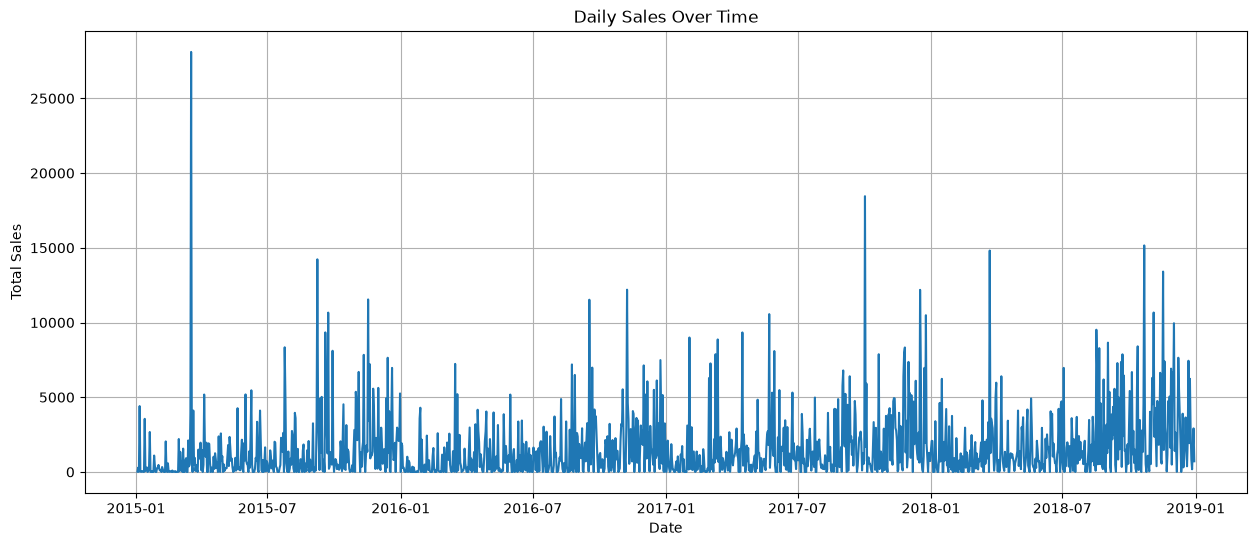

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(daily_sales)

plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

### 30-Day Rolling Average

Daily sales can contain substantial short-term fluctuations. A 30-day rolling average is used to smooth these fluctuations and make the underlying sales trend easier to identify.

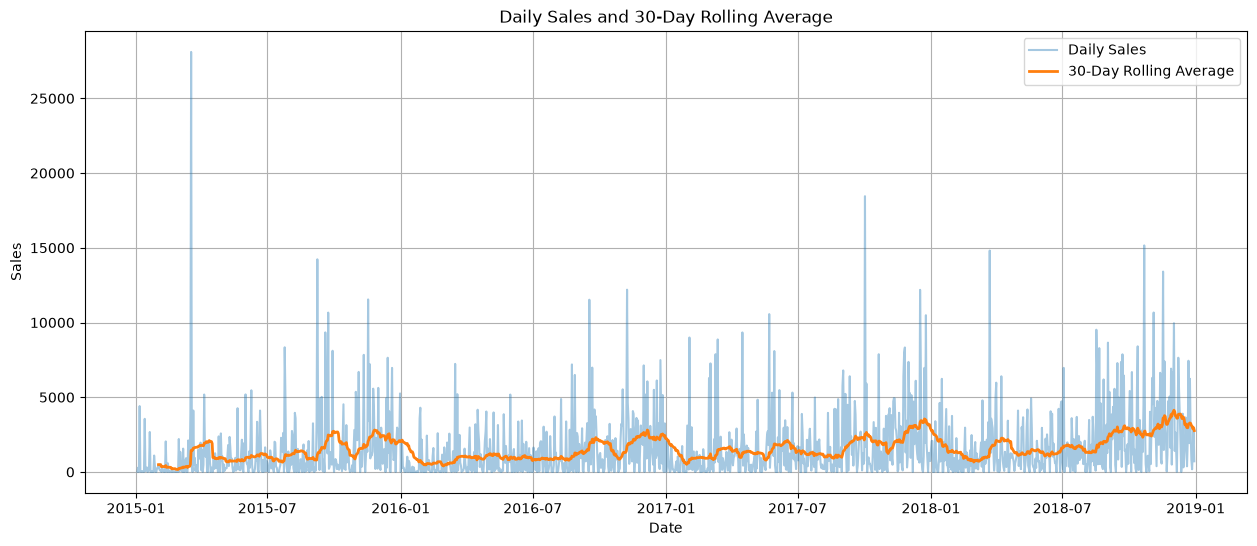

In [39]:
rolling_30 = daily_sales.rolling(window=30).mean()

plt.figure(figsize=(15, 6))

plt.plot(daily_sales, alpha=0.4, label="Daily Sales")
plt.plot(rolling_30, linewidth=2, label="30-Day Rolling Average")

plt.title("Daily Sales and 30-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

### Monthly Sales Trend

Monthly sales are aggregated to identify broader long-term patterns and fluctuations in sales over the historical period.

In [40]:
monthly_sales = daily_sales.resample("MS").sum()

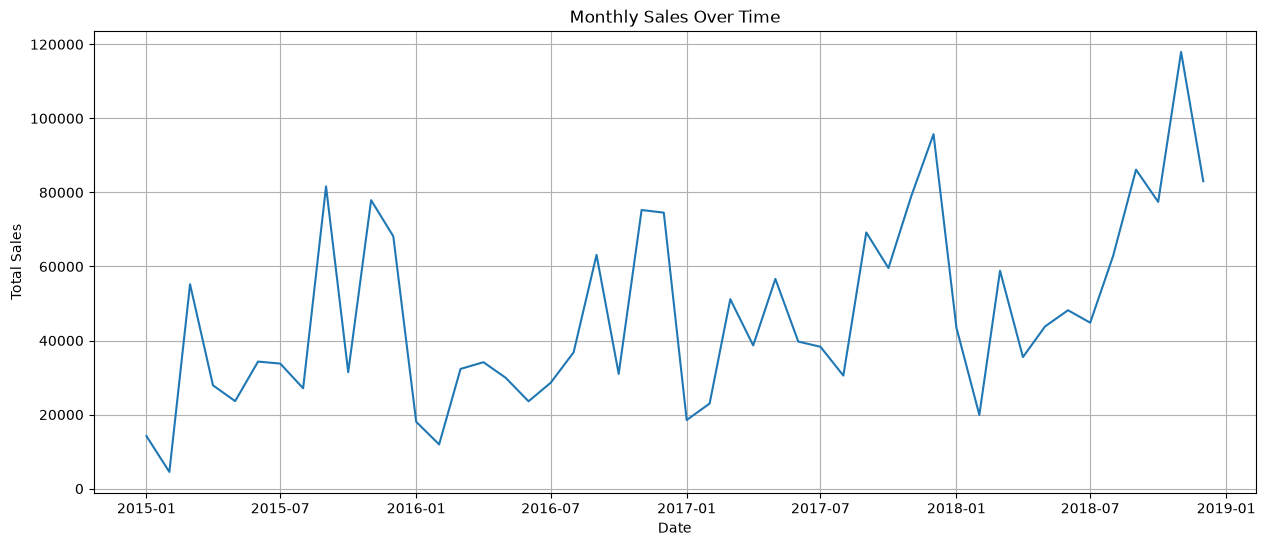

In [41]:
plt.figure(figsize=(15, 6))

plt.plot(monthly_sales)

plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

In [42]:
monthly_seasonality = monthly_sales.groupby(
    monthly_sales.index.month
).mean()

monthly_seasonality

1     23572.907400
2     14842.778850
3     49393.396800
4     34070.750150
5     38521.680925
6     36459.380825
7     36383.922250
8     39328.981750
9     75025.852925
10    49874.073675
11    87540.427750
12    80370.042375
Name: Sales, dtype: float64

## 5. Stationarity Analysis

Stationarity is an important consideration in time-series forecasting because some forecasting methods, particularly ARIMA-family models, require or benefit from a stationary series.

The Augmented Dickey-Fuller (ADF) test is applied to determine whether the daily sales series provides statistical evidence of stationarity.

In [43]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(daily_sales)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.9265833751962385
p-value: 3.094891245873619e-05


In [44]:
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Conclusion: The series is likely stationary.")
else:
    print("Conclusion: The series is likely non-stationary.")

ADF Statistic: -4.9265833751962385
p-value: 3.094891245873619e-05
Conclusion: The series is likely stationary.


## 6. Autocorrelation Analysis

Autocorrelation is examined to determine whether current sales are related to previous observations. The ACF helps identify the strength of relationships at different time lags, while the PACF helps identify more direct lag relationships.

The first 30 lags are examined initially to investigate short-term dependencies in daily sales.

<Figure size 1200x500 with 0 Axes>

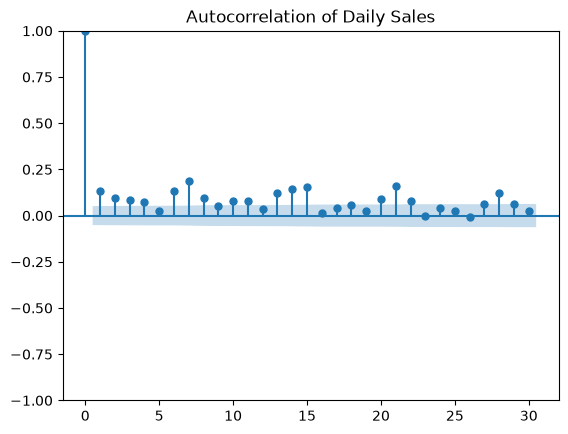

In [45]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(daily_sales, lags=30)

plt.title("Autocorrelation of Daily Sales")
plt.show()

<Figure size 1200x500 with 0 Axes>

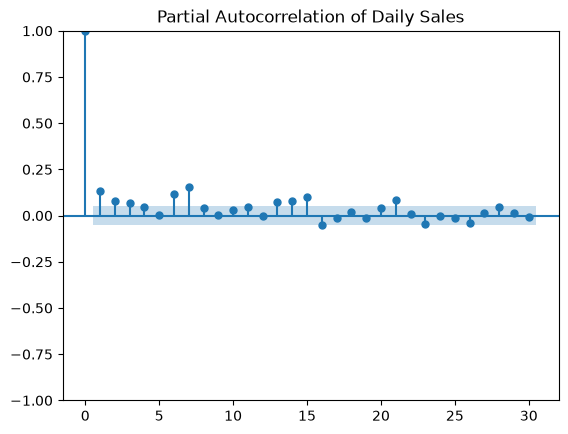

In [46]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 5))

plot_pacf(daily_sales, lags=30, method="ywm")

plt.title("Partial Autocorrelation of Daily Sales")
plt.show()

## 7. Weekly Seasonality Analysis

The ACF indicated potential weekly seasonality through noticeable autocorrelation around lags 7, 14, and 21. Sales are therefore compared across days of the week to determine whether systematic weekday differences are present.

In [47]:
daily_df = daily_sales.to_frame(name="Sales")

daily_df["DayOfWeek"] = daily_df.index.day_name()

daily_df.head()

,Sales,DayOfWeek
2015-01-03,16.448,Saturday
2015-01-04,288.060,Sunday
2015-01-05,19.536,Monday
2015-01-06,4407.100,Tuesday
2015-01-07,87.158,Wednesday


In [48]:
weekday_sales = (
    daily_df.groupby("DayOfWeek")["Sales"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

weekday_sales

DayOfWeek
Monday       1676.882460
Tuesday      2021.807328
Wednesday    1518.696982
Thursday      686.727116
Friday       1128.417501
Saturday     2013.882662
Sunday       1807.984583
Name: Sales, dtype: float64

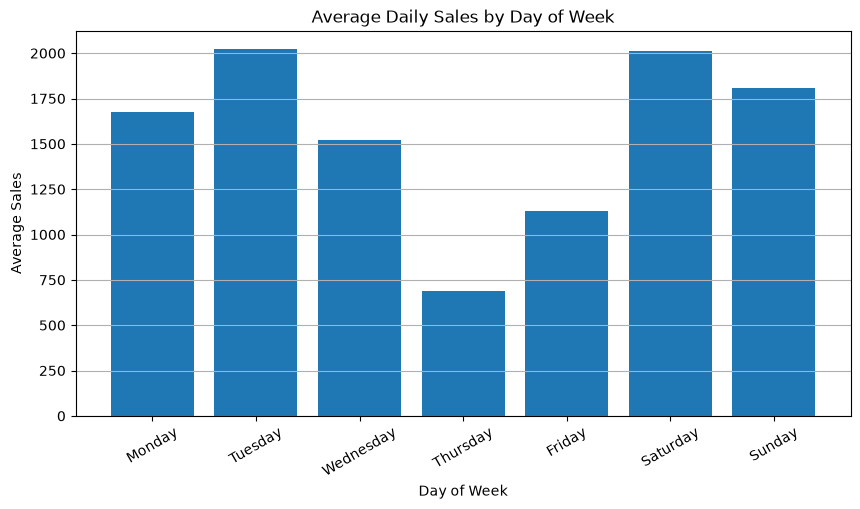

In [49]:
plt.figure(figsize=(10, 5))

plt.bar(weekday_sales.index, weekday_sales.values)

plt.title("Average Daily Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

## 8. Time-Series Decomposition

The daily sales series is decomposed into trend, seasonal, and residual components. A weekly period of 7 days is used because both the ACF analysis and weekday comparison provided evidence of weekly seasonality.

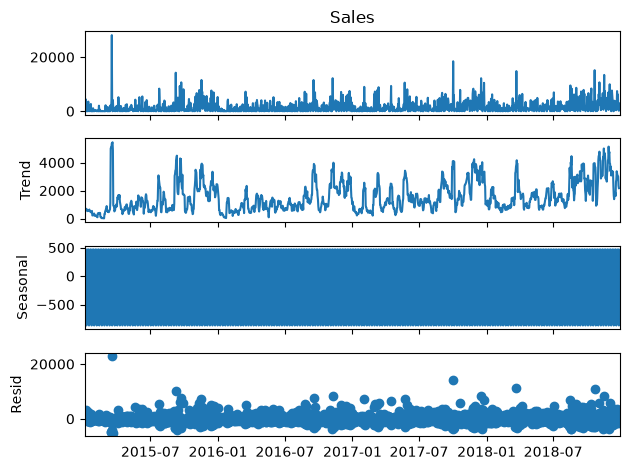

In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    daily_sales,
    model="additive",
    period=7
)

decomposition.plot()

plt.show()

In [51]:
seasonal_component = decomposition.seasonal

seasonal_by_day = (
    seasonal_component.groupby(seasonal_component.index.day_name())
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

seasonal_by_day

Monday       130.209237
Tuesday      470.150149
Wednesday    -34.951328
Thursday    -867.213590
Friday      -429.371704
Saturday     465.121192
Sunday       266.056044
Name: seasonal, dtype: float64

## 9. Train-Test Split

Because sales forecasting is a temporal prediction problem, the dataset is divided chronologically rather than randomly. The earlier observations are used for model training, while the most recent observations are reserved as an unseen test period.

Approximately 80% of the observations are used for training and 20% for testing.

In [52]:
split_index = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:split_index]
test = daily_sales.iloc[split_index:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period:", test.index.min(), "to", test.index.max())

Training observations: 1166
Testing observations: 292
Training period: 2015-01-03 00:00:00 to 2018-03-13 00:00:00
Testing period: 2018-03-14 00:00:00 to 2018-12-30 00:00:00


## 10. Baseline Model — Naive Forecast

A naive forecasting model is established as a benchmark. The forecast for each test observation is set equal to the previous day's actual sales.

This baseline provides a reference against which more sophisticated forecasting models can be evaluated.

In [53]:
naive_forecast = test.shift(1)

In [54]:
naive_forecast = test.copy()

naive_forecast.iloc[0] = train.iloc[-1]

naive_forecast.iloc[1:] = test.iloc[:-1].values

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

naive_mae = mean_absolute_error(test, naive_forecast)

naive_rmse = np.sqrt(
    mean_squared_error(test, naive_forecast)
)

print("Naive Baseline MAE:", naive_mae)
print("Naive Baseline RMSE:", naive_rmse)

Naive Baseline MAE: 2366.7490883561645
Naive Baseline RMSE: 3382.2148243544293


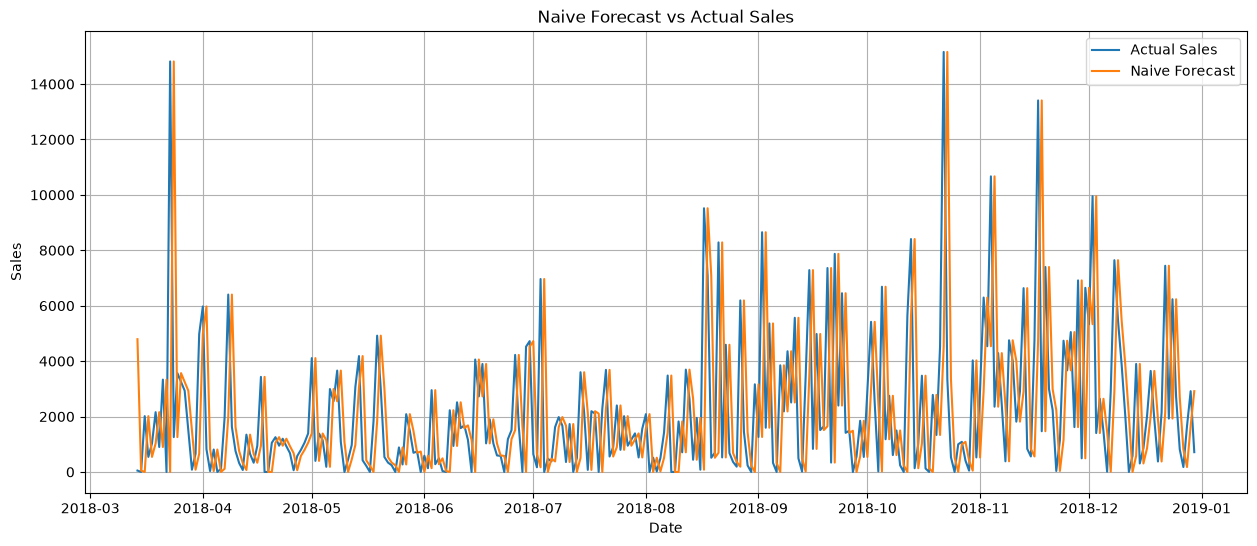

In [56]:
plt.figure(figsize=(15, 6))

plt.plot(test.index, test.values, label="Actual Sales")
plt.plot(test.index, naive_forecast.values, label="Naive Forecast")

plt.title("Naive Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

## 11. Seasonal Naive Baseline

Because exploratory analysis identified a weekly seasonal pattern, a seasonal naive model is evaluated as an additional benchmark. Each forecast is based on the observed sales value from the same day one week earlier.

This provides a stronger baseline than the ordinary naive forecast while remaining simple and interpretable.

In [57]:
seasonal_naive_forecast = test.copy()

for i in range(len(test)):
    if i < 7:
        seasonal_naive_forecast.iloc[i] = daily_sales.loc[
            test.index[i] - pd.Timedelta(days=7)
        ]
    else:
        seasonal_naive_forecast.iloc[i] = test.iloc[i - 7]

In [58]:
seasonal_naive_mae = mean_absolute_error(
    test,
    seasonal_naive_forecast
)

seasonal_naive_rmse = np.sqrt(
    mean_squared_error(
        test,
        seasonal_naive_forecast
    )
)

print("Seasonal Naive MAE:", seasonal_naive_mae)
print("Seasonal Naive RMSE:", seasonal_naive_rmse)

Seasonal Naive MAE: 2140.039790410959
Seasonal Naive RMSE: 3300.736426466382


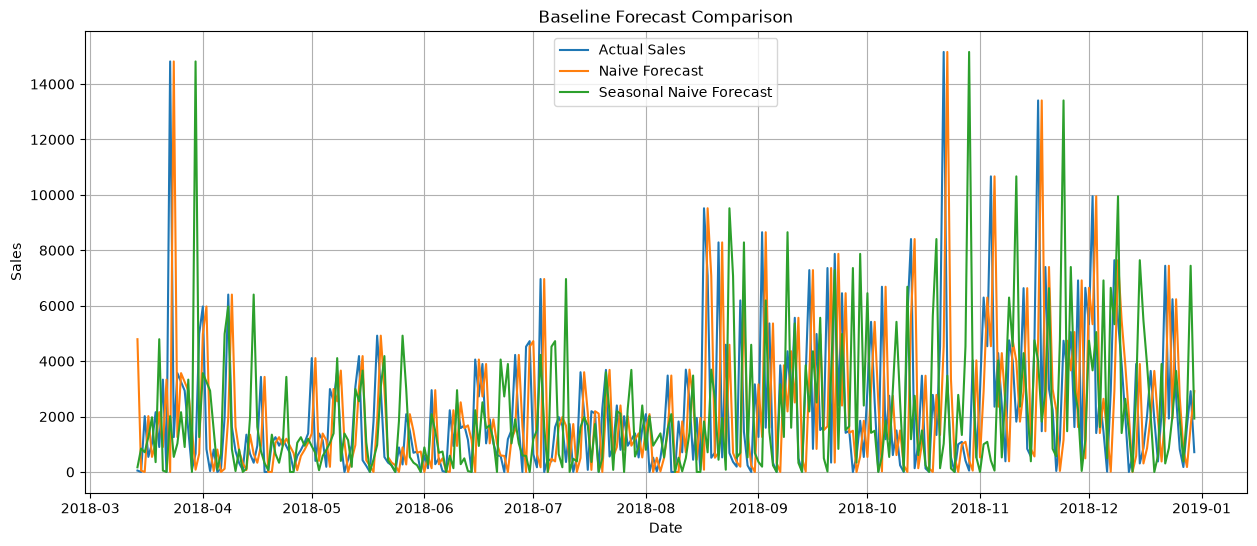

In [59]:
plt.figure(figsize=(15, 6))

plt.plot(
    test.index,
    test.values,
    label="Actual Sales"
)

plt.plot(
    test.index,
    naive_forecast.values,
    label="Naive Forecast"
)

plt.plot(
    test.index,
    seasonal_naive_forecast.values,
    label="Seasonal Naive Forecast"
)

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

## 12. ARIMA Forecasting

An ARIMA model is introduced as the first statistical forecasting approach. Based on the ADF test, the original daily sales series provides evidence against a unit root, so the initial model uses no differencing (`d=0`).

An initial ARIMA(1,0,0) model is fitted to the training data and evaluated on the unseen test period.

In [60]:
from statsmodels.tsa.arima.model import ARIMA

arima_100 = ARIMA(
    train,
    order=(1, 0, 0)
)

arima_100_fit = arima_100.fit()

arima_100_forecast = arima_100_fit.forecast(
    steps=len(test)
)

In [61]:
arima_100_mae = mean_absolute_error(
    test,
    arima_100_forecast
)

arima_100_rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_100_forecast
    )
)

print("ARIMA(1,0,0) MAE:", arima_100_mae)
print("ARIMA(1,0,0) RMSE:", arima_100_rmse)

ARIMA(1,0,0) MAE: 1703.6248287026444
ARIMA(1,0,0) RMSE: 2632.484496636885


## 13. Seasonal ARIMA (SARIMA)

The exploratory analysis identified a weekly seasonal pattern in daily sales. A Seasonal ARIMA model is therefore introduced to explicitly model both short-term autoregressive behavior and weekly seasonal dependence.

The initial model uses a weekly seasonal period of 7 days:
SARIMA(1,0,0)(1,0,0,7).

In [62]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_100_100 = SARIMAX(
    train,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_100_100_fit = sarima_100_100.fit(disp=False)

sarima_forecast = sarima_100_100_fit.forecast(
    steps=len(test)
)

In [63]:
sarima_mae = mean_absolute_error(
    test,
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_forecast
    )
)

print("SARIMA(1,0,0)(1,0,0,7) MAE:", sarima_mae)
print("SARIMA(1,0,0)(1,0,0,7) RMSE:", sarima_rmse)

SARIMA(1,0,0)(1,0,0,7) MAE: 2195.282950219912
SARIMA(1,0,0)(1,0,0,7) RMSE: 3326.0073686541914


## 14. ARIMA Model Comparison

Several small ARIMA configurations are evaluated using the same chronological train-test split. Model performance is compared using MAE and RMSE on the unseen test period.

In [64]:
def evaluate_arima(order):
    model = ARIMA(train, order=order)
    fitted_model = model.fit()

    forecast = fitted_model.forecast(steps=len(test))

    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))

    return mae, rmse, fitted_model, forecast

In [65]:
arima_orders = [
    (1, 0, 0),
    (2, 0, 0),
    (0, 0, 1),
    (1, 0, 1)
]

results = []

for order in arima_orders:
    mae, rmse, fitted_model, forecast = evaluate_arima(order)

    results.append({
        "Model": f"ARIMA{order}",
        "MAE": mae,
        "RMSE": rmse
    })

arima_results = pd.DataFrame(results)

arima_results.sort_values("RMSE")

,Model,MAE,RMSE
2,"ARIMA(0, 0, 1)",1703.396748,2632.347149
0,"ARIMA(1, 0, 0)",1703.624829,2632.484497
3,"ARIMA(1, 0, 1)",1700.681853,2632.607595
1,"ARIMA(2, 0, 0)",1703.888448,2632.643144


## Residual Diagnostics

In [66]:
best_order = (0, 0, 1)

best_mae, best_rmse, best_model, best_forecast = evaluate_arima(
    best_order
)

print("Selected model:", best_order)
print("MAE:", best_mae)
print("RMSE:", best_rmse)

Selected model: (0, 0, 1)
MAE: 1703.3967476312507
RMSE: 2632.3471492821564


In [67]:
residuals = best_model.resid

residuals.head()

2015-01-03   -1371.777838
2015-01-04    -951.776727
2015-01-05   -1264.514448
2015-01-06    3157.299226
2015-01-07   -1646.694638
Freq: D, dtype: float64

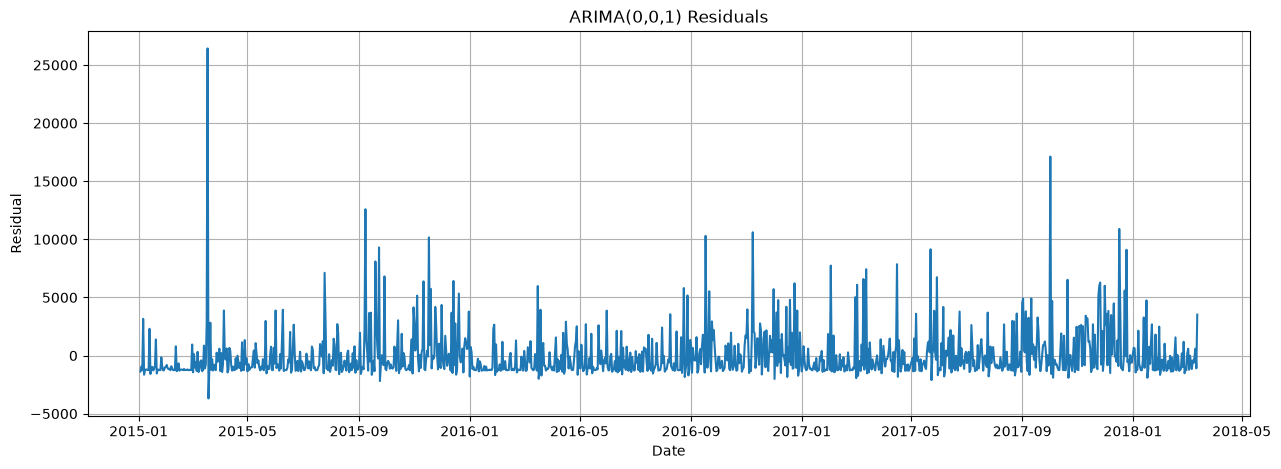

In [68]:
plt.figure(figsize=(15, 5))

plt.plot(residuals)

plt.title("ARIMA(0,0,1) Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)

plt.show()

<Figure size 1200x500 with 0 Axes>

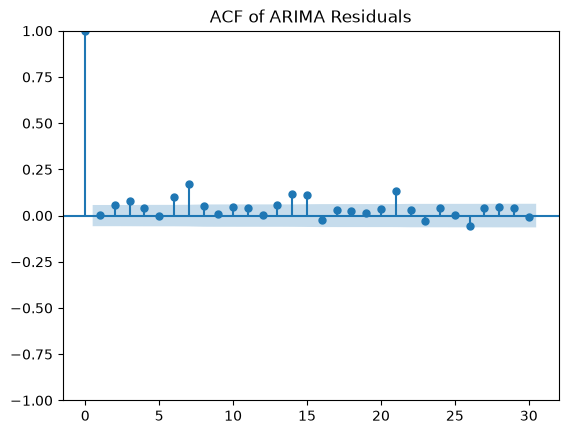

In [69]:
plt.figure(figsize=(12, 5))

plot_acf(residuals, lags=30)

plt.title("ACF of ARIMA Residuals")

plt.show()

In [70]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals,
    lags=[7, 14, 21],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
7,59.793323,1.660002e-10
14,87.670020,1.043526e-12
21,128.536071,1.898945e-17


## 16. Seasonal Model Refinement

Residual diagnostics from the initial ARIMA model showed significant autocorrelation at weekly-related lags. This indicates that additional temporal structure remains unexplained.

A seasonal ARIMA configuration is therefore tested using a 7-day seasonal period while retaining the non-seasonal MA component that performed well in the earlier ARIMA comparison.

In [71]:
sarima_001_101 = SARIMAX(
    train,
    order=(0, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_001_101_fit = sarima_001_101.fit(disp=False)

sarima_001_101_forecast = sarima_001_101_fit.forecast(
    steps=len(test)
)

In [72]:
sarima_001_101_mae = mean_absolute_error(
    test,
    sarima_001_101_forecast
)

sarima_001_101_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_001_101_forecast
    )
)

print(
    "SARIMA(0,0,1)(1,0,1,7) MAE:",
    sarima_001_101_mae
)

print(
    "SARIMA(0,0,1)(1,0,1,7) RMSE:",
    sarima_001_101_rmse
)

SARIMA(0,0,1)(1,0,1,7) MAE: 1549.2646491149649
SARIMA(0,0,1)(1,0,1,7) RMSE: 2401.90733294972


In [73]:
sarima_residuals = sarima_001_101_fit.resid

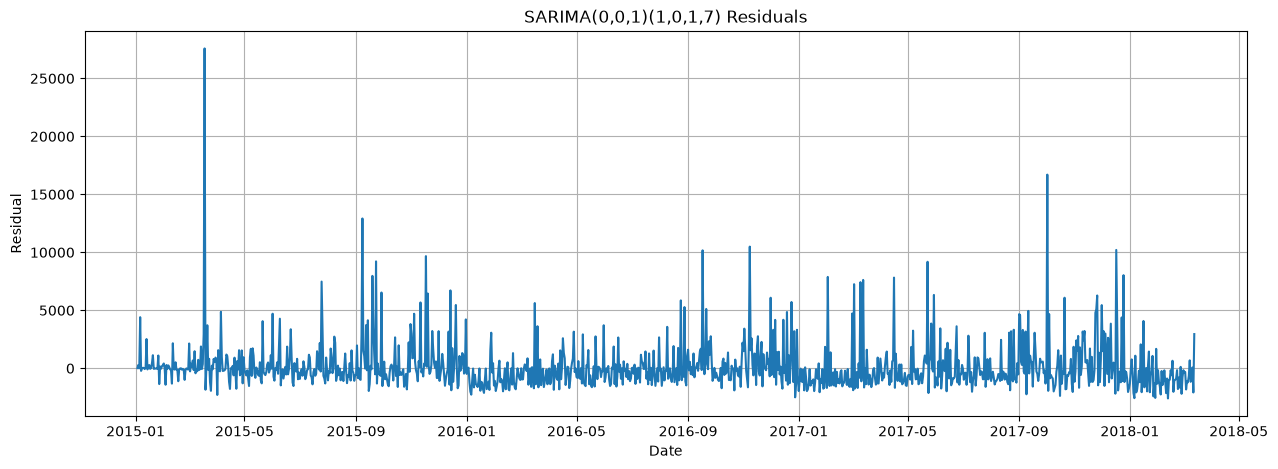

In [74]:
plt.figure(figsize=(15, 5))

plt.plot(sarima_residuals)

plt.title("SARIMA(0,0,1)(1,0,1,7) Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)

plt.show()

<Figure size 1200x500 with 0 Axes>

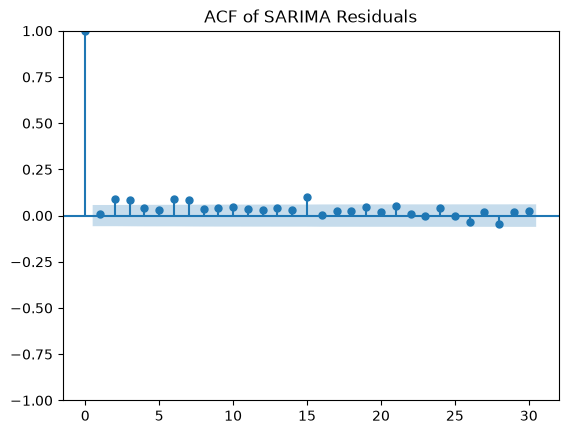

In [75]:
plt.figure(figsize=(12, 5))

plot_acf(
    sarima_residuals,
    lags=30
)

plt.title("ACF of SARIMA Residuals")

plt.show()

In [76]:
sarima_ljung_box = acorr_ljungbox(
    sarima_residuals,
    lags=[7, 14, 21],
    return_df=True
)

sarima_ljung_box

,lb_stat,lb_pvalue
7,39.380712,1.653326e-06
14,51.152406,3.910001e-06
21,70.059429,3.437756e-07


## 17. SARIMA Model Refinement

Although SARIMA(0,0,1)(1,0,1,7) improved forecast accuracy, residual diagnostics indicate significant remaining autocorrelation.

A second seasonal specification, SARIMA(1,0,1)(1,0,1,7), is therefore evaluated to determine whether incorporating a regular autoregressive component improves both forecasting accuracy and residual behavior.

In [77]:
sarima_101_101 = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_101_101_fit = sarima_101_101.fit(disp=False)

sarima_101_101_forecast = sarima_101_101_fit.forecast(
    steps=len(test)
)

In [78]:
sarima_101_101_mae = mean_absolute_error(
    test,
    sarima_101_101_forecast
)

sarima_101_101_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_101_101_forecast
    )
)

print(
    "SARIMA(1,0,1)(1,0,1,7) MAE:",
    sarima_101_101_mae
)

print(
    "SARIMA(1,0,1)(1,0,1,7) RMSE:",
    sarima_101_101_rmse
)

SARIMA(1,0,1)(1,0,1,7) MAE: 1556.0585499049782
SARIMA(1,0,1)(1,0,1,7) RMSE: 2497.008295228543


In [79]:
model_comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "ARIMA(1,0,0)",
        "ARIMA(0,0,1)",
        "ARIMA(1,0,1)",
        "ARIMA(2,0,0)",
        "SARIMA(1,0,0)(1,0,0,7)",
        "SARIMA(0,0,1)(1,0,1,7)",
        "SARIMA(1,0,1)(1,0,1,7)"
    ],
    "MAE": [
        naive_mae,
        seasonal_naive_mae,
        1703.6248287026444,
        1703.396748,
        1700.681853,
        1703.888448,
        sarima_mae,
        sarima_001_101_mae,
        sarima_101_101_mae
    ],
    "RMSE": [
        naive_rmse,
        seasonal_naive_rmse,
        2632.484496636885,
        2632.347149,
        2632.607595,
        2632.643144,
        sarima_rmse,
        sarima_001_101_rmse,
        sarima_101_101_rmse
    ]
})

model_comparison.sort_values("RMSE")

,Model,MAE,RMSE
7,"SARIMA(0,0,1)(1,0,1,7)",1549.264649,2401.907333
8,"SARIMA(1,0,1)(1,0,1,7)",1556.058550,2497.008295
3,"ARIMA(0,0,1)",1703.396748,2632.347149
2,"ARIMA(1,0,0)",1703.624829,2632.484497
4,"ARIMA(1,0,1)",1700.681853,2632.607595
5,"ARIMA(2,0,0)",1703.888448,2632.643144
1,Seasonal Naive,2140.039790,3300.736426
6,"SARIMA(1,0,0)(1,0,0,7)",2195.282950,3326.007369
0,Naive,2366.749088,3382.214824


## 18. Walk-Forward Validation

To reduce dependence on a single train-test split, walk-forward validation is used within the training period. The model is repeatedly fitted using only historical observations and evaluated on subsequent observations.

The final test set remains untouched and will be used only for the final model evaluation.

In [80]:
def walk_forward_validation(
    series,
    order,
    seasonal_order,
    initial_train_size,
    horizon=30
):
    results = []

    for end in range(
        initial_train_size,
        len(series) - horizon + 1,
        horizon
    ):
        train_fold = series.iloc[:end]
        validation_fold = series.iloc[end:end + horizon]

        model = SARIMAX(
            train_fold,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

        forecast = fitted_model.forecast(
            steps=horizon
        )

        mae = mean_absolute_error(
            validation_fold,
            forecast
        )

        rmse = np.sqrt(
            mean_squared_error(
                validation_fold,
                forecast
            )
        )

        results.append({
            "Train_End": train_fold.index[-1],
            "MAE": mae,
            "RMSE": rmse
        })

    return pd.DataFrame(results)

In [81]:
validation_results = walk_forward_validation(
    train,
    order=(0, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    initial_train_size=800,
    horizon=30
)

validation_results

,Train_End,MAE,RMSE
0,2017-03-12,1108.029548,1727.277115
1,2017-04-11,1189.070549,1828.135229
2,2017-05-11,1518.755576,2474.889109
3,2017-06-10,1142.504765,1367.899278
4,2017-07-10,958.869201,1106.312177
5,2017-08-09,1509.998726,2006.723394
6,2017-09-08,1709.652165,3534.686632
7,2017-10-08,1509.282229,1910.596918
8,2017-11-07,1954.747075,2656.008477
9,2017-12-07,1960.421087,2985.365059


In [82]:
print(
    "Average Validation MAE:",
    validation_results["MAE"].mean()
)

print(
    "Average Validation RMSE:",
    validation_results["RMSE"].mean()
)

Average Validation MAE: 1439.4066763845249
Average Validation RMSE: 2062.188994509743


In [83]:
validation_results.describe()

,Train_End,MAE,RMSE
count,12,12.000000,12.000000
mean,2017-08-24 00:00:00,1439.406676,2062.188995
min,2017-03-12 00:00:00,958.869201,1106.312177
25%,2017-06-02 12:00:00,1177.429103,1641.276182
50%,2017-08-24 00:00:00,1483.475796,1869.366074
75%,2017-11-14 12:00:00,1566.479723,2520.168951
max,2018-02-05 00:00:00,1960.421087,3534.686632
std,NaN,323.689830,716.334575


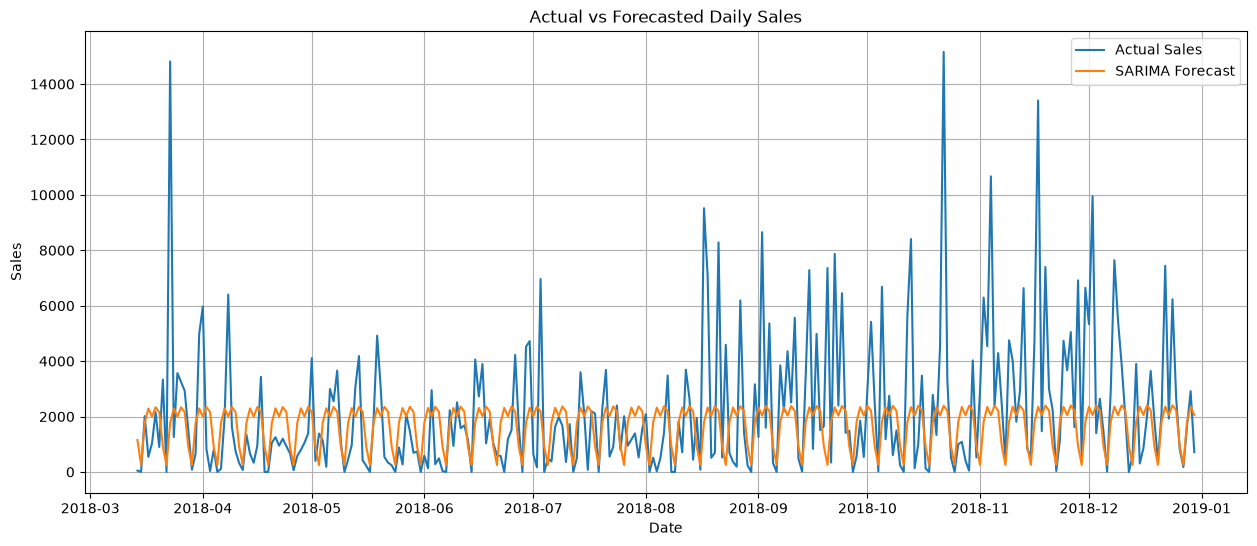

In [84]:
plt.figure(figsize=(15, 6))

plt.plot(
    test.index,
    test,
    label="Actual Sales"
)

plt.plot(
    test.index,
    sarima_001_101_forecast,
    label="SARIMA Forecast"
)

plt.title(
    "Actual vs Forecasted Daily Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [85]:
mae_improvement = (
    (naive_mae - sarima_001_101_mae)
    / naive_mae
) * 100

rmse_improvement = (
    (naive_rmse - sarima_001_101_rmse)
    / naive_rmse
) * 100

print(
    f"MAE improvement: {mae_improvement:.2f}%"
)

print(
    f"RMSE improvement: {rmse_improvement:.2f}%"
)

MAE improvement: 34.54%
RMSE improvement: 28.98%


In [86]:
print(daily_sales.index.min())
print(daily_sales.index.max())
print(len(daily_sales))

2015-01-03 00:00:00
2018-12-30 00:00:00
1458


## 19. Final Model Selection

Based on the holdout test evaluation and walk-forward validation results, SARIMA(0,0,1)(1,0,1,7) was selected as the final forecasting model.

The model incorporates both short-term temporal dependencies and weekly seasonal behavior, using a seasonal period of 7 days.

On the holdout test set, the model achieved:

- **MAE:** 1,549.26
- **RMSE:** 2,401.91

Compared with the Naive baseline, the final model reduced MAE by 34.54% and RMSE by 28.98%.

The model was selected based on predictive performance rather than model complexity. Walk-forward validation was additionally used to assess whether its performance remained stable across multiple historical periods.

In [87]:
final_model = SARIMAX(
    daily_sales,
    order=(0, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_model_fit = final_model.fit(disp=False)

print(final_model_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             Sales   No. Observations:                 1458
Model:             SARIMAX(0, 0, 1)x(1, 0, 1, 7)   Log Likelihood              -13211.462
Date:                           Tue, 01 Sep 2026   AIC                          26430.925
Time:                                   20:43:32   BIC                          26452.039
Sample:                               01-03-2015   HQIC                         26438.804
                                    - 12-30-2018                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0684      0.041      1.677      0.094      -0.012       0.148
ar.S.L7        1.0041      0.003    358.276

## 20. 90-Day Future Sales Forecast

The selected SARIMA model was used to generate a 90-day sales forecast beyond the final date available in the historical dataset.

Prediction intervals are also generated to represent uncertainty around the expected future sales values. The forecast is intended to provide an estimate of future demand and support planning and decision-making rather than represent exact future sales.

In [88]:
forecast_steps = 90

future_forecast = final_model_fit.forecast(
    steps=forecast_steps
)

future_forecast.head()

2018-12-31    3134.454642
2019-01-01    3141.044699
2019-01-02    1355.663286
2019-01-03     608.351793
2019-01-04    3085.958331
Freq: D, Name: predicted_mean, dtype: float64

In [89]:
future_dates = pd.date_range(
    start=daily_sales.index.max() + pd.Timedelta(days=1),
    periods=forecast_steps,
    freq="D"
)

future_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Sales": future_forecast.values
})

future_forecast_df.head()

,Date,Forecasted_Sales
0,2018-12-31,3134.454642
1,2019-01-01,3141.044699
2,2019-01-02,1355.663286
3,2019-01-03,608.351793
4,2019-01-04,3085.958331


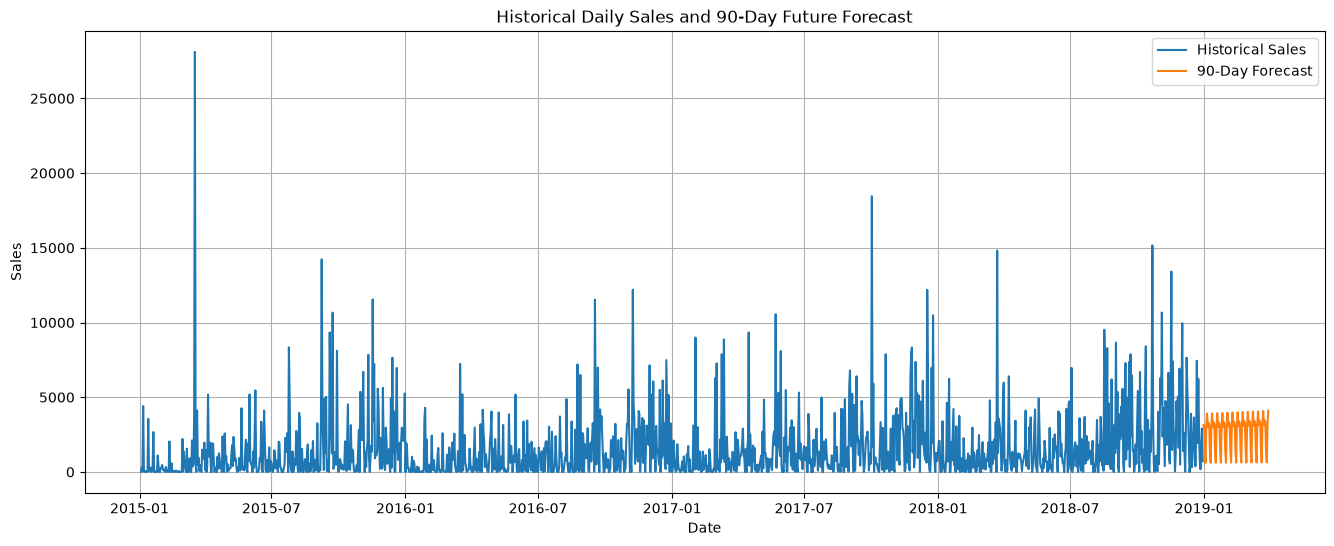

In [90]:
plt.figure(figsize=(16, 6))

plt.plot(
    daily_sales.index,
    daily_sales,
    label="Historical Sales"
)

plt.plot(
    future_forecast_df["Date"],
    future_forecast_df["Forecasted_Sales"],
    label="90-Day Forecast"
)

plt.title(
    "Historical Daily Sales and 90-Day Future Forecast"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [91]:
forecast_result = final_model_fit.get_forecast(
    steps=forecast_steps
)

forecast_summary = forecast_result.summary_frame(
    alpha=0.05
)

forecast_summary.head()

Sales,mean,mean_se,mean_ci_lower,mean_ci_upper
2018-12-31,3134.454642,2634.150771,-2028.385998,8297.295283
2019-01-01,3141.044699,2640.300819,-2033.849815,8315.939213
2019-01-02,1355.663286,2640.300819,-3819.231228,6530.557800
2019-01-03,608.351793,2640.300819,-4566.542721,5783.246307
2019-01-04,3085.958331,2640.300819,-2088.936183,8260.852845


In [92]:
future_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Sales": forecast_summary["mean"].values,
    "Lower_Bound": forecast_summary["mean_ci_lower"].values,
    "Upper_Bound": forecast_summary["mean_ci_upper"].values
})

future_forecast_df.head()

,Date,Forecasted_Sales,Lower_Bound,Upper_Bound
0,2018-12-31,3134.454642,-2028.385998,8297.295283
1,2019-01-01,3141.044699,-2033.849815,8315.939213
2,2019-01-02,1355.663286,-3819.231228,6530.557800
3,2019-01-03,608.351793,-4566.542721,5783.246307
4,2019-01-04,3085.958331,-2088.936183,8260.852845


## 21. Forecast Visualization

The historical daily sales series is plotted together with the 90-day forecast and its prediction interval.

This visualization allows the expected future sales trajectory to be compared with historical behavior while also communicating the uncertainty associated with the forecast.

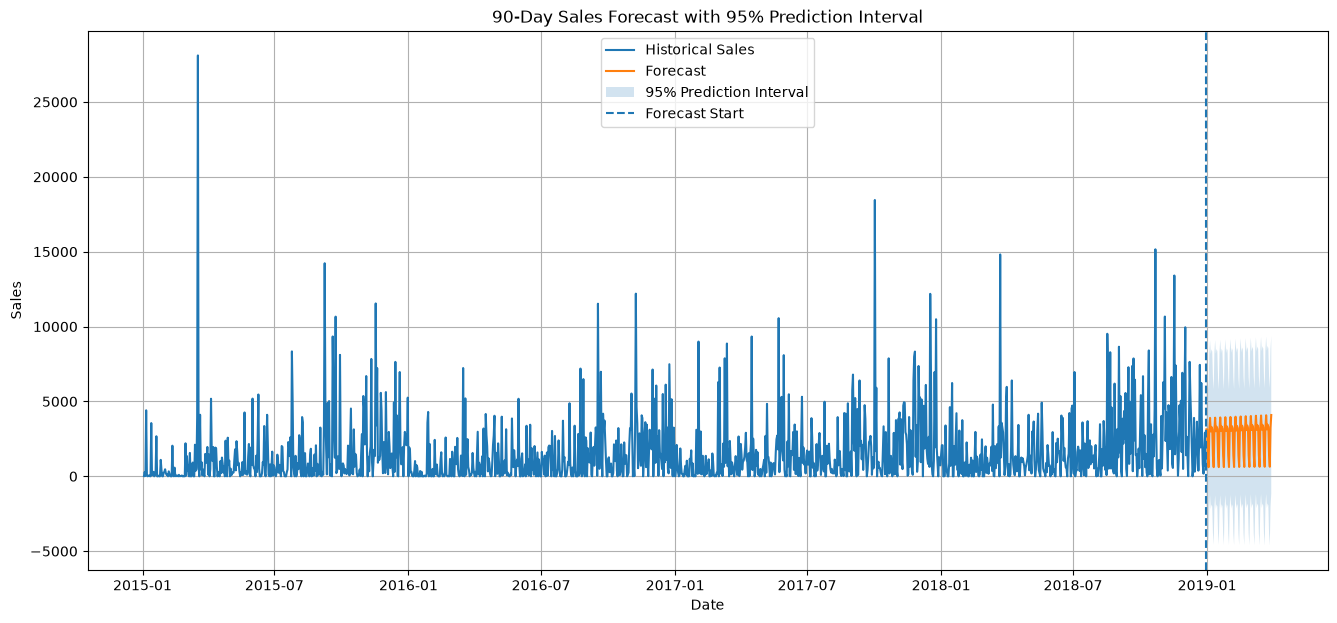

In [93]:
plt.figure(figsize=(16, 7))

#Historical_sales
plt.plot(
    daily_sales.index,
    daily_sales,
    label="Historical Sales"
)

#Forecast
plt.plot(
    future_forecast_df["Date"],
    future_forecast_df["Forecasted_Sales"],
    label="Forecast"
)

#Prediction_interval
plt.fill_between(
    future_forecast_df["Date"],
    future_forecast_df["Lower_Bound"],
    future_forecast_df["Upper_Bound"],
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.axvline(
    daily_sales.index.max(),
    linestyle="--",
    label="Forecast Start"
)

plt.title(
    "90-Day Sales Forecast with 95% Prediction Interval"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

## 22. Forecast Summary

The 90-day forecast is summarized using key statistics to provide a concise view of expected future sales.

The summary includes total expected sales, average expected daily sales, and the highest and lowest forecasted sales days. These statistics provide a business-oriented interpretation of the model output.

In [94]:
forecast_summary_stats = {
    "Total Forecasted Sales": future_forecast_df["Forecasted_Sales"].sum(),
    "Average Daily Forecast": future_forecast_df["Forecasted_Sales"].mean(),
    "Minimum Daily Forecast": future_forecast_df["Forecasted_Sales"].min(),
    "Maximum Daily Forecast": future_forecast_df["Forecasted_Sales"].max()
}

forecast_summary_stats

{'Total Forecasted Sales': np.float64(241453.10907274886),
 'Average Daily Forecast': np.float64(2682.8123230305428),
 'Minimum Daily Forecast': np.float64(608.3517929972467),
 'Maximum Daily Forecast': np.float64(4092.921908994507)}

In [95]:
future_forecast_df.sort_values(
    "Forecasted_Sales",
    ascending=False
).head(10)

,Date,Forecasted_Sales,Lower_Bound,Upper_Bound
89,2019-03-30,4092.921909,-1163.698062,9349.541880
82,2019-03-23,4076.368525,-1173.183891,9325.920941
75,2019-03-16,4059.882090,-1182.650411,9302.414591
68,2019-03-09,4043.462332,-1192.097622,9279.022287
61,2019-03-02,4027.108983,-1201.525525,9255.743491
54,2019-02-23,4010.821772,-1210.934120,9232.577665
47,2019-02-16,3994.600434,-1220.323407,9209.524274
40,2019-02-09,3978.444701,-1229.693385,9186.582787
33,2019-02-02,3962.354308,-1239.044055,9163.752671
26,2019-01-26,3946.328991,-1248.375416,9141.033398


In [96]:
future_forecast_df.sort_values(
    "Forecasted_Sales",
    ascending=True
).head(10)

,Date,Forecasted_Sales,Lower_Bound,Upper_Bound
3,2019-01-03,608.351793,-4566.542721,5783.246307
10,2019-01-10,610.822198,-4570.630547,5792.274942
17,2019-01-17,613.302635,-4574.753321,5801.358590
24,2019-01-24,615.793144,-4578.911263,5810.497551
31,2019-01-31,618.293767,-4583.104596,5819.692129
38,2019-02-07,620.804544,-4587.333542,5828.942630
45,2019-02-14,623.325517,-4591.598323,5838.249358
52,2019-02-21,625.856728,-4595.899165,5847.612620
59,2019-02-28,628.398217,-4600.236291,5857.032725
66,2019-03-07,630.950027,-4604.609928,5866.509981


In [97]:
future_forecast_df["Lower_Bound_Clipped"] = (
    future_forecast_df["Lower_Bound"].clip(lower=0)
)

In [98]:
monthly_forecast = (
    future_forecast_df
    .set_index("Date")["Forecasted_Sales"]
    .resample("MS")
    .sum()
)

monthly_forecast

Date
2018-12-01     3134.454642
2019-01-01    79181.516405
2019-02-01    75287.049239
2019-03-01    83850.088786
Freq: MS, Name: Forecasted_Sales, dtype: float64

## 23. Monthly Forecast Analysis

The daily forecast is aggregated by month to identify how expected sales are distributed across the 90-day forecast horizon.

Monthly aggregation provides a higher-level view that can be useful for sales planning, inventory management, and resource allocation.

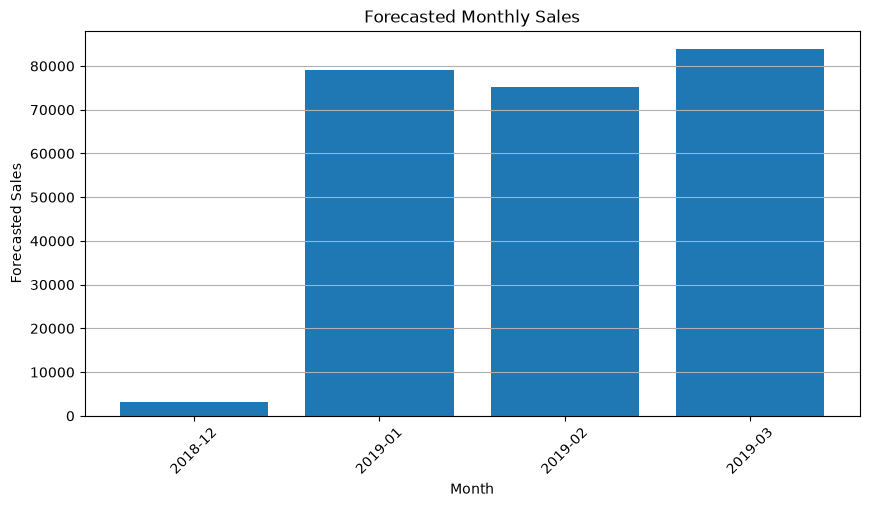

In [99]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_forecast.index.strftime("%Y-%m"),
    monthly_forecast.values
)

plt.title("Forecasted Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")
plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

In [100]:
monthly_forecast.sort_values(
    ascending=False
)

Date
2019-03-01    83850.088786
2019-01-01    79181.516405
2019-02-01    75287.049239
2018-12-01     3134.454642
Name: Forecasted_Sales, dtype: float64

## 24. Weekday Forecast Analysis

The forecast is further grouped by day of the week to examine expected differences in sales throughout the weekly cycle.

This analysis helps identify which weekdays are expected to contribute relatively higher or lower sales during the forecast period and provides additional insight into recurring weekly demand patterns.

In [101]:
future_forecast_df["DayOfWeek"] = (
    future_forecast_df["Date"].dt.day_name()
)

weekday_forecast = (
    future_forecast_df
    .groupby("DayOfWeek")["Forecasted_Sales"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

weekday_forecast

DayOfWeek
Monday       3355.304534
Tuesday      3218.727110
Wednesday    1389.190728
Thursday      623.397180
Friday       3162.278379
Saturday     3995.059687
Sunday       3065.138338
Name: Forecasted_Sales, dtype: float64

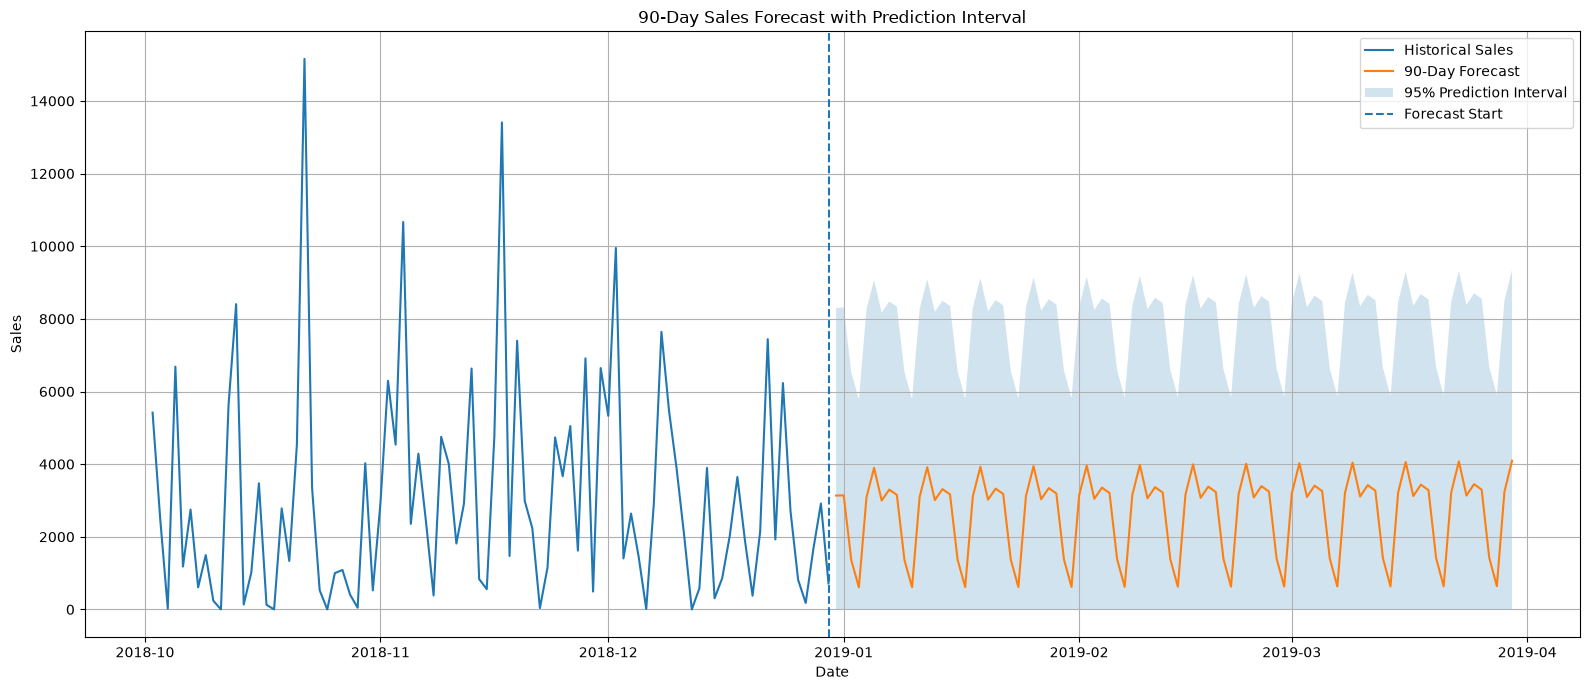

In [102]:
plt.figure(figsize=(16, 7))

#Last_90_days_of_historical_sales
historical_recent = daily_sales.tail(90)

plt.plot(
    historical_recent.index,
    historical_recent.values,
    label="Historical Sales"
)

#Future_forecast
plt.plot(
    future_forecast_df["Date"],
    future_forecast_df["Forecasted_Sales"],
    label="90-Day Forecast"
)

#Prediction_interval
plt.fill_between(
    future_forecast_df["Date"],
    future_forecast_df["Lower_Bound_Clipped"],
    future_forecast_df["Upper_Bound"],
    alpha=0.2,
    label="95% Prediction Interval"
)

#Forecast_start
plt.axvline(
    daily_sales.index.max(),
    linestyle="--",
    label="Forecast Start"
)

plt.title(
    "90-Day Sales Forecast with Prediction Interval"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

In [103]:
future_forecast_df["Lower_Bound_Clipped"] = (
    future_forecast_df["Lower_Bound"].clip(lower=0)
)

In [104]:
forecast_report = pd.DataFrame({
    "Metric": [
        "Forecast Horizon",
        "Total Forecasted Sales",
        "Average Daily Forecast",
        "Minimum Daily Forecast",
        "Maximum Daily Forecast",
        "Highest Forecast Day",
        "Lowest Forecast Day"
    ],
    "Value": [
        "90 days",
        round(future_forecast_df["Forecasted_Sales"].sum(), 2),
        round(future_forecast_df["Forecasted_Sales"].mean(), 2),
        round(future_forecast_df["Forecasted_Sales"].min(), 2),
        round(future_forecast_df["Forecasted_Sales"].max(), 2),
        future_forecast_df.loc[
            future_forecast_df["Forecasted_Sales"].idxmax(),
            "Date"
        ].strftime("%Y-%m-%d"),
        future_forecast_df.loc[
            future_forecast_df["Forecasted_Sales"].idxmin(),
            "Date"
        ].strftime("%Y-%m-%d")
    ]
})

forecast_report

,Metric,Value
0,Forecast Horizon,90 days
1,Total Forecasted Sales,241453.11
2,Average Daily Forecast,2682.81
3,Minimum Daily Forecast,608.35
4,Maximum Daily Forecast,4092.92
5,Highest Forecast Day,2019-03-30
6,Lowest Forecast Day,2019-01-03


In [105]:
monthly_forecast_full = (
    future_forecast_df
    .set_index("Date")["Forecasted_Sales"]
    .resample("MS")
    .sum()
)

monthly_forecast_complete = monthly_forecast_full[
    monthly_forecast_full.index >= "2019-01-01"
]

monthly_forecast_complete

Date
2019-01-01    79181.516405
2019-02-01    75287.049239
2019-03-01    83850.088786
Freq: MS, Name: Forecasted_Sales, dtype: float64

In [106]:
highest_month = monthly_forecast_complete.idxmax()
highest_month_value = monthly_forecast_complete.max()

lowest_month = monthly_forecast_complete.idxmin()
lowest_month_value = monthly_forecast_complete.min()

print(
    "Highest forecast month:",
    highest_month.strftime("%B %Y"),
    f"({highest_month_value:,.2f})"
)

print(
    "Lowest forecast month:",
    lowest_month.strftime("%B %Y"),
    f"({lowest_month_value:,.2f})"
)

Highest forecast month: March 2019 (83,850.09)
Lowest forecast month: February 2019 (75,287.05)


In [107]:
saturday_forecast = weekday_forecast["Saturday"]
thursday_forecast = weekday_forecast["Thursday"]

difference = saturday_forecast - thursday_forecast

percentage_difference = (
    difference / thursday_forecast
) * 100

print(
    f"Saturday vs Thursday difference: "
    f"{difference:,.2f}"
)

print(
    f"Saturday is approximately "
    f"{percentage_difference:.2f}% higher than Thursday."
)

Saturday vs Thursday difference: 3,371.66
Saturday is approximately 540.85% higher than Thursday.


In [108]:
from pathlib import Path

Path("D:\\DATA SCIENCE MINDRISERS CLASS\\Sales-Forecasting\\data\\processed").mkdir(
    parents=True,
    exist_ok=True
)

In [109]:
forecast_output_path = (
    "D:\\DATA SCIENCE MINDRISERS CLASS\\Sales-Forecasting\\data\\processed\\90_day_sales_forecast.csv"
)

future_forecast_df.to_csv(
    forecast_output_path,
    index=False
)

print(
    f"Forecast saved to: {forecast_output_path}"
)

Forecast saved to: D:\DATA SCIENCE MINDRISERS CLASS\Sales-Forecasting\data\processed\90_day_sales_forecast.csv


In [110]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "ARIMA(0,0,1)",
        "ARIMA(1,0,0)",
        "ARIMA(1,0,1)",
        "ARIMA(2,0,0)",
        "SARIMA(1,0,0)(1,0,0,7)",
        "SARIMA(0,0,1)(1,0,1,7)",
        "SARIMA(1,0,1)(1,0,1,7)"
    ],
    "MAE": [
        2366.749088,
        2140.039790,
        1703.396748,
        1703.624829,
        1700.681853,
        1703.888448,
        2195.282951,
        1549.264649,
        1556.058550
    ],
    "RMSE": [
        3382.214824,
        3300.736426,
        2632.347149,
        2632.484497,
        2632.607595,
        2632.643145,
        3326.007369,
        2401.907333,
        2497.008295
    ]
})

final_model_comparison = final_model_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

final_model_comparison

,Model,MAE,RMSE
0,"SARIMA(0,0,1)(1,0,1,7)",1549.264649,2401.907333
1,"SARIMA(1,0,1)(1,0,1,7)",1556.058550,2497.008295
2,"ARIMA(1,0,1)",1700.681853,2632.607595
3,"ARIMA(0,0,1)",1703.396748,2632.347149
4,"ARIMA(1,0,0)",1703.624829,2632.484497
5,"ARIMA(2,0,0)",1703.888448,2632.643145
6,Seasonal Naive,2140.039790,3300.736426
7,"SARIMA(1,0,0)(1,0,0,7)",2195.282951,3326.007369
8,Naive,2366.749088,3382.214824


## Final Model Selection

Based on the holdout test evaluation and walk-forward validation, SARIMA(0,0,1)(1,0,1,7) was selected as the final forecasting model.

The model achieved a test MAE of 1,549.26 and RMSE of 2,401.91, representing improvements of 34.54% and 28.98% respectively over the naive baseline.

Walk-forward validation across 12 validation folds produced an average MAE of 1,439.41 and RMSE of 2,062.19, indicating that the model maintained reasonable forecasting performance across multiple historical periods.

## Business Insights

- The final SARIMA model forecasts approximately 241.45K in total sales over the 90-day forecast horizon, with an average expected daily sales value of approximately 2.68K.

- The forecast indicates a clear weekly pattern, with Saturday having the highest average expected sales at approximately 3.995K and Thursday having the lowest at approximately 0.623K.

- Among the complete forecast months, March 2019 has the highest projected sales, while February 2019 has the lowest.

- The forecasting model reduced MAE by 34.54% and RMSE by 28.98% compared with the naive baseline, demonstrating improved predictive performance over a simple historical approach.

- The prediction intervals indicate substantial uncertainty around individual daily forecasts. Therefore, the forecasts should be used as planning estimates rather than exact daily sales predictions.

## Conclusion

This project developed an end-to-end time-series forecasting workflow for historical sales data. The analysis began with data cleaning and exploratory analysis before investigating temporal patterns, stationarity, and weekly seasonality.

Multiple forecasting approaches were evaluated, including naive forecasting, seasonal naive forecasting, ARIMA, and SARIMA. Among the evaluated models, SARIMA(0,0,1)(1,0,1,7) achieved the best overall performance, with a holdout test MAE of 1,549.26 and RMSE of 2,401.91.

Compared with the naive baseline, the final model reduced MAE by 34.54% and RMSE by 28.98%. Walk-forward validation further demonstrated consistent performance across 12 historical validation folds.

The final model was then retrained using the complete historical dataset and used to generate a 90-day future sales forecast. The forecast suggests approximately 241.45K in total sales over the forecast horizon, while also revealing substantial variation across days of the week.

Overall, the project demonstrates how time-series analysis and statistical forecasting can transform historical sales data into useful forward-looking information for business planning and decision-making.